In [3]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import re
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

warnings.simplefilter(action="ignore", category=FutureWarning,)

In [4]:
df = pd.read_csv("../data/nairobi_housing.csv")
df.head()

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,KSh 350 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
1,KSh 30 000 000,Vacant Land,Karen,NaN,NaN,NaN,0.5 acres
2,KSh 325 000 000,Vacant Land,Westlands,NaN,NaN,NaN,0.5 acres
3,KSh 80 000 000,Townhouse,Kitisuru,5.0,5.0,NaN,0.5 acres
4,KSh 25 500 000,Apartment,Kileleshwa,4.0,4.0,230 m²,NaN


In [5]:
def clean_data(df):
    # Clean Price: Remove 'KSh', commas, and spaces
    df['Price'] = df['Price'].str.replace(r'[KSh, ]', '', regex=True)
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [6]:
# Clean House Size: Extract numbers from '230 m²'
df['House size'] = df['House size'].str.extract(r'(\d+)').astype(float)

In [7]:
# Standardize Land Size to Acres
def standardize_land(val):
    if pd.isna(val): 
        return 0
    val = str(val).lower()
    num = float(re.findall(r"[-+]?\d*\.\d+|\d+", val)[0])
    if 'acre' in val: 
        return num
    if 'hectare' in val: 
        return num * 2.47
    if '50x100' in val: 
        return 0.115
    return 0

df['Land_Acres'] = df['Land size'].apply(standardize_land)


In [8]:
def clean_data(df):

    # Fill Missing Values
    df['Bedroom'] = df['Bedroom'].fillna(df['Bedroom'].median())
    df['bathroom'] = df['bathroom'].fillna(df['bathroom'].median())

    return df


df_clean = clean_data(df)


In [9]:
df['Price'] = (
    df['Price']
    .str.replace(r'[^\d.]', '', regex=True)
    .astype(float)
)


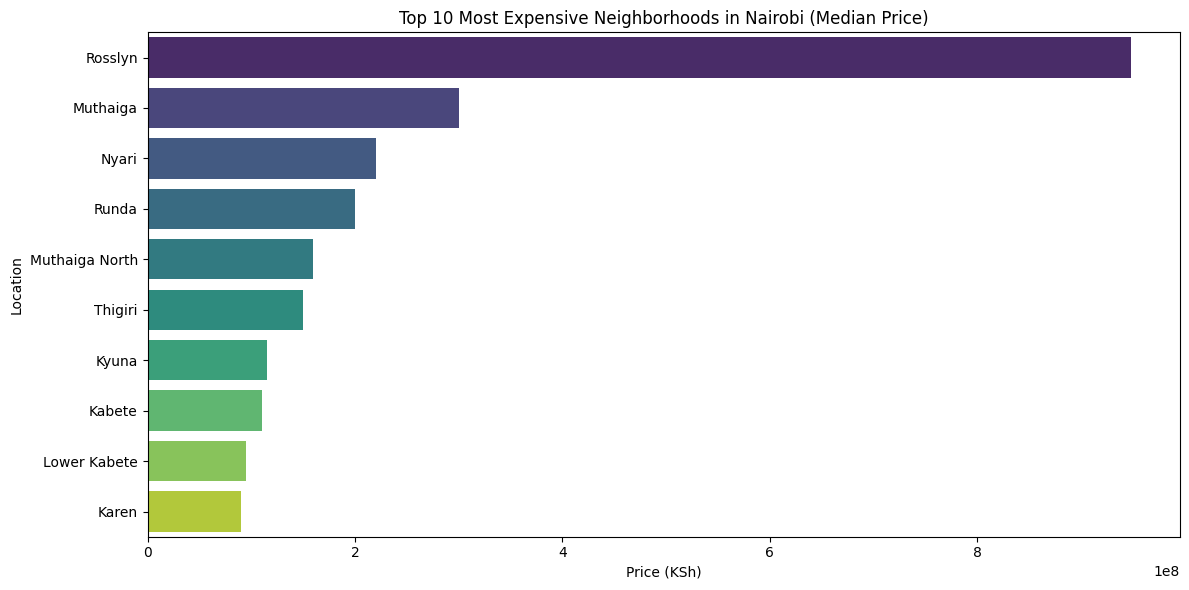

In [10]:
plt.figure(figsize=(12, 6))
# Top 10 most expensive locations
top_locations = df_clean.groupby('Location')['Price'].median().sort_values(ascending=False).head(10)
sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis')
plt.title('Top 10 Most Expensive Neighborhoods in Nairobi (Median Price)')
plt.xlabel('Price (KSh)')
plt.tight_layout()
plt.savefig("../images/top_10_expensive_locations.png", dpi=300)
plt.show()

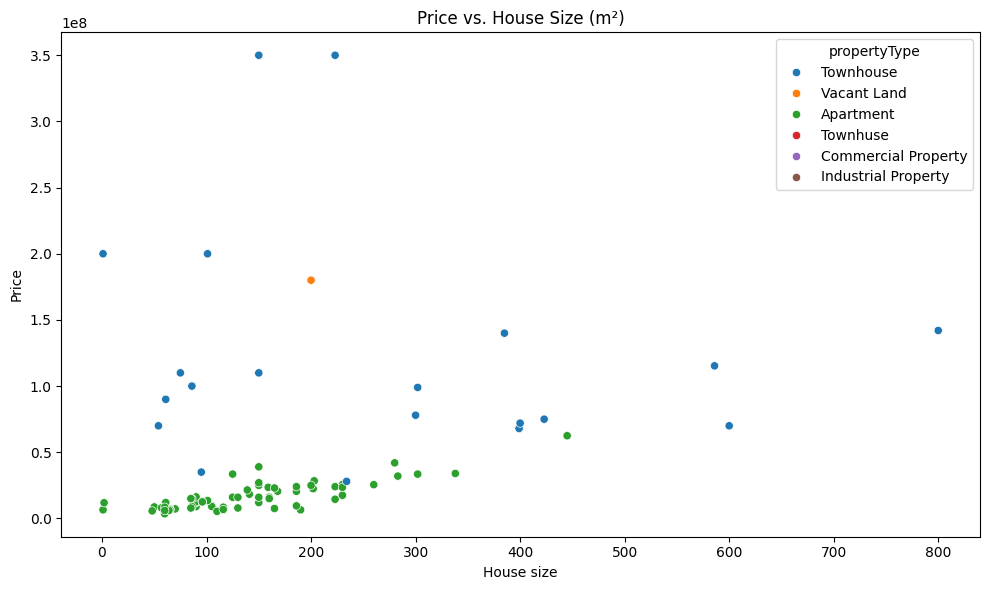

In [11]:
# Price vs House Size Correlation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='House size', y='Price', hue='propertyType')
plt.title('Price vs. House Size (m²)')
plt.tight_layout()
plt.savefig("../images/price_vs_size_scatter.png", dpi=300)
plt.show()

In [12]:
# Feature Engineering: One-Hot Encode Location and Property Type
df_ml = pd.get_dummies(df_clean, columns=['Location', 'propertyType'], drop_first=True)

In [13]:
# Define X and y
X = df_ml.drop(['Price', 'Land size'], axis=1).select_dtypes(include=[np.number])
y = df_ml['Price']

In [14]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [16]:
# Evaluate
preds = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, preds):.2f}")
print(f"Mean Absolute Error: KSh {mean_absolute_error(y_test, preds):,.0f}")

R2 Score: 0.72
Mean Absolute Error: KSh 45,970,579


In [17]:
# 1. Feature Importance (Assuming 'model' is your trained Random Forest)
features = X_train.columns
importances = model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

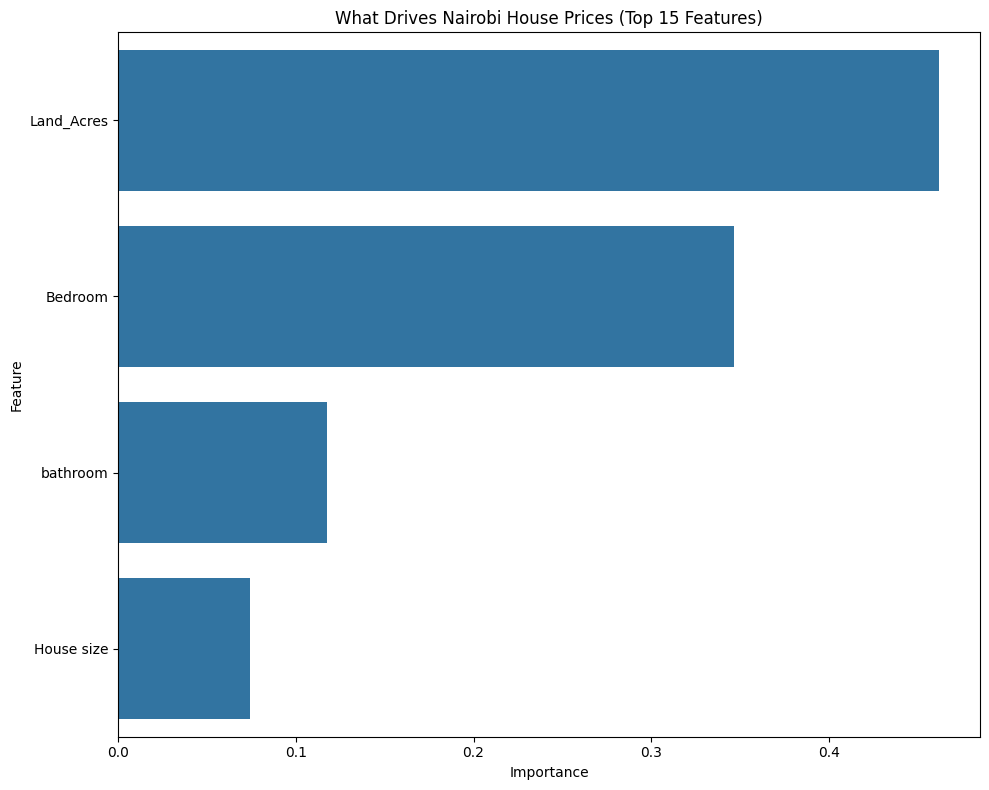

In [18]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(15))
plt.title('What Drives Nairobi House Prices (Top 15 Features)')
plt.tight_layout()
plt.savefig("../images/feature_importance.png", dpi=300)
plt.show()

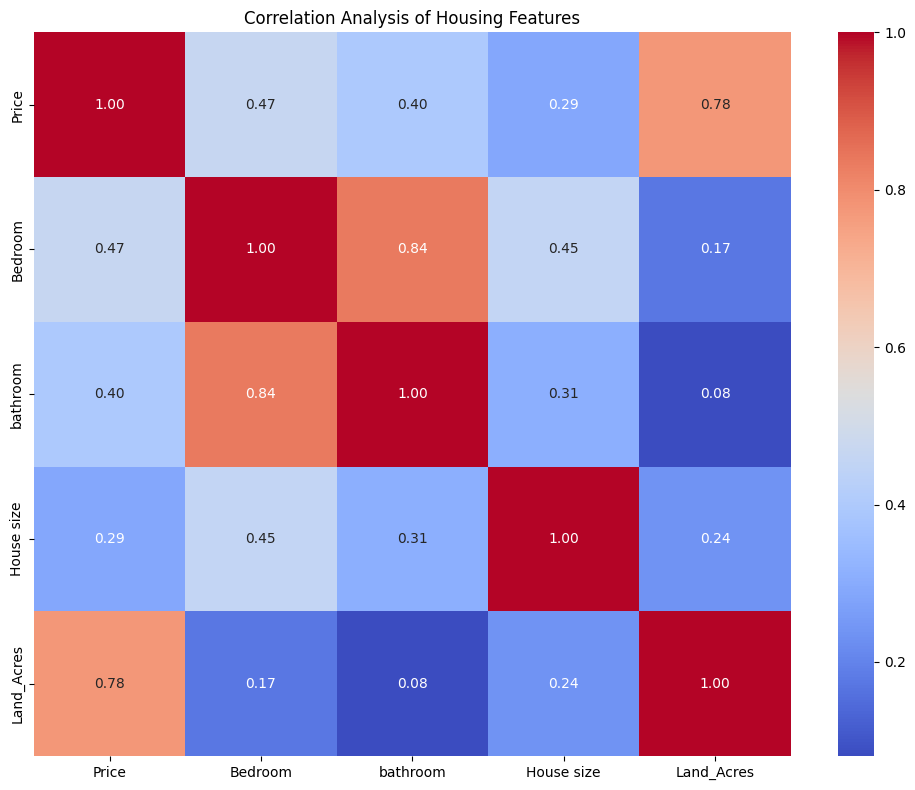

In [19]:
plt.figure(figsize=(10, 8))

numeric_df = df_clean.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Analysis of Housing Features')

plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=300)
plt.show()



In [22]:
# 3. Interactive Price Distribution by Location 
fig = px.box(df_clean, x="Location", y="Price", color="propertyType",
             title="Price Distribution across Nairobi Neighborhoods")
#  fig.write_html("../images/price_distribution_by_location.html") 
fig.show()

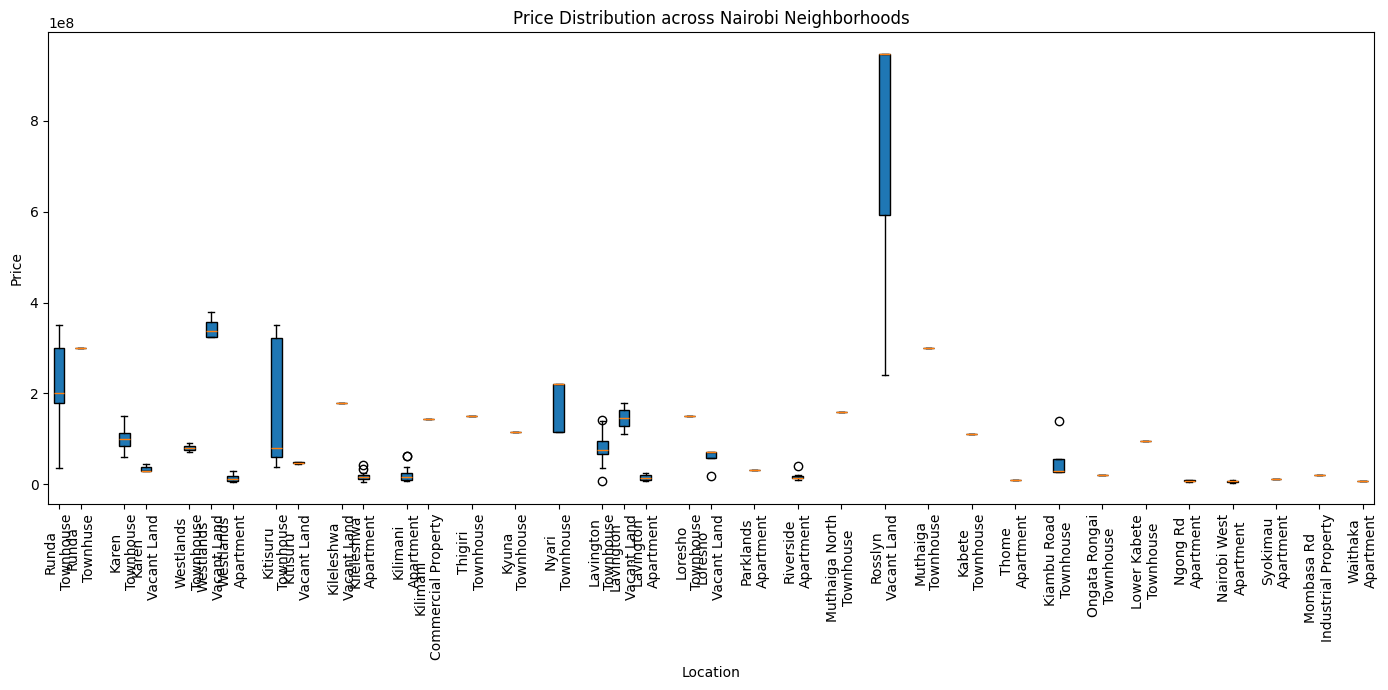

In [24]:
#df_clean["Price"] = pd.to_numeric(df_clean["Price"], errors="coerce")

plt.figure(figsize=(14, 7))

# Get unique categories
locations = df_clean["Location"].unique()
property_types = df_clean["propertyType"].unique()

# Create grouped boxplots
positions = []
data = []
labels = []
pos = 0

for loc in locations:
    for ptype in property_types:
        subset = df_clean[
            (df_clean["Location"] == loc) &
            (df_clean["propertyType"] == ptype)
        ]["Price"].dropna()
        
        if len(subset) > 0:
            data.append(subset)
            positions.append(pos)
            labels.append(f"{loc}\n{ptype}")
            pos += 1
    pos += 1  # Space between locations

plt.boxplot(data, positions=positions, patch_artist=True)

plt.xticks(positions, labels, rotation=90)
plt.title("Price Distribution across Nairobi Neighborhoods")
plt.xlabel("Location")
plt.ylabel("Price")

plt.tight_layout()

# Save as image 
plt.savefig("../images/price_distribution_by_location.png")

plt.show()